In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
%reload_ext autoreload
import time, os
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

from models.network import HCNet
from models.utils.utils import get_homograpy
# from models.utils.loss_factory import zod_se2_loss
import dataset as datasets
import json
from easydict import EasyDict
import argparse
import shlex


from models.utils.utils import *
from models.utils.loss_factory import *


In [3]:
args_str = "--iters_lev0 6 --CNN16 --flow --batch_size 1 --p_siamese --ori_noise 45 --restore_ckpt checkpoints/2026_01_09_14_36_50_best_checkpoint_zod.pth"
parser = argparse.ArgumentParser()
parser.add_argument('--config', type=str, default="models/config/ZOD/train.json")
parser.add_argument('--dropout', type=float, default=0.0)
parser.add_argument('--start_step', type=int, default=0)
parser.add_argument('--batch_size', type=int, default=None)
parser.add_argument('--name', default='HC-Net')
parser.add_argument('--restore_ckpt', type=str, default=None)
parser.add_argument('--validation', type=str, nargs='+', default=None)
parser.add_argument('--best_dis', type=float, default=1e8)

# add the flags you want to accept
parser.add_argument('--iters_lev0', type=int, default=6)
parser.add_argument('--ori_noise', type=float, default=45.0)
parser.add_argument('--CNN16', action='store_true')
parser.add_argument('--flow', action='store_true')
parser.add_argument('--p_siamese', action='store_true')

args = parser.parse_args(shlex.split(args_str))  # key line [web:462][web:479]
print(args)


config = json.load(open("models/config/ZOD/train.json",'r'))
config = EasyDict(config)
config['config'] = "models/config/ZOD/train.json"
config['best_dis'] = 1e8
config['validation'] = args.validation
config['name'] = args.name
config['restore_ckpt'] = args.restore_ckpt
config['start_step'] = args.start_step
if args.batch_size: 
    config['batch_size'] = args.batch_size

print(config)

setup_seed(2023)
print_colored(time.strftime('%Y-%m-%d %H:%M:%S',time.localtime(time.time())))

if not os.path.isdir('checkpoints'):
    os.mkdir('checkpoints')
if config.dataset=='vigor':
    print("Dataset is VIGOR!")  


Namespace(config='models/config/ZOD/train.json', dropout=0.0, start_step=0, batch_size=1, name='HC-Net', restore_ckpt='checkpoints/2026_01_09_14_36_50_best_checkpoint_zod.pth', validation=None, best_dis=100000000.0, iters_lev0=6, ori_noise=45.0, CNN16=True, flow=True, p_siamese=True)
{'gpuid': [0], 'mixed_precision': False, 'iters_lev0': 6, 'lev0': True, 'flow': True, 'p_siamese': True, 'CNN16': True, 'log_every': 10, 'dataset': 'zod', 'orig_label': False, 'cross_area': False, 'batch_size': 1, 'lr': 0.00035, 'num_steps': 76000, 'scheduler': 'OneCycle', 'loss_w': [0.1, 30.0, 100000.0], 'temperature': 4.0, 'augment': False, 'ori_noise': 45.0, 'orien': True, 'restore_ckpt': 'checkpoints/2026_01_09_14_36_50_best_checkpoint_zod.pth', 'model': None, 'wdecay': 0.0005, 'epsilon': 1e-07, 'clip': 1.0, 'gamma': 0.85, 'name': 'HC-Net', 'validation': None, 'image_size': 512, 'zoom': 20, 'IMG_FREQ': 20000, 'SUM_FREQ': 100, 'use_augmentation': True, 'image_area_dg_m': 51.2, 'image_area_zod_m': 100, '

In [4]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
args = config
args.gpuid = [0]          # pick GPU id you want
model = HCNet(args).to(device)
ckpt = torch.load(args.restore_ckpt, map_location=device)
state = ckpt.get("model", ckpt)
state = { (k[7:] if k.startswith("module.") else k): v for k,v in state.items() }
model.load_state_dict(state, strict=False)
model.eval()


Loaded pretrained weights for efficientnet-b0


/tmp/2776263/ipykernel_2508130/4240677133.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(args.restore_ckpt, map_location=device)


HCNet(
  (sat_efficientnet): EfficientNet(
    (_conv_stem): Conv2dStaticSamePadding(
      3, 32, kernel_size=(3, 3), stride=(2, 2), bias=False
      (static_padding): ZeroPad2d((0, 1, 0, 1))
    )
    (_bn0): BatchNorm2d(32, eps=0.001, momentum=0.010000000000000009, affine=True, track_running_stats=True)
    (_blocks): ModuleList(
      (0): MBConvBlock(
        (_depthwise_conv): Conv2dStaticSamePadding(
          32, 32, kernel_size=(3, 3), stride=[1, 1], groups=32, bias=False
          (static_padding): ZeroPad2d((1, 1, 1, 1))
        )
        (_bn1): BatchNorm2d(32, eps=0.001, momentum=0.010000000000000009, affine=True, track_running_stats=True)
        (_se_reduce): Conv2dStaticSamePadding(
          32, 8, kernel_size=(1, 1), stride=(1, 1)
          (static_padding): Identity()
        )
        (_se_expand): Conv2dStaticSamePadding(
          8, 32, kernel_size=(1, 1), stride=(1, 1)
          (static_padding): Identity()
        )
        (_project_conv): Conv2dStaticSamePadd

# Loading Validation dataset

In [148]:
%reload_ext autoreload
from torch.utils.data import DataLoader
import dataset.ZOD as datasets


# Use your dataset
val_dataset = datasets.fetch_dataloader(args, split="val")

# inspection collate (keeps points as a list)
def zod_collate_inspect(batch):
    batch = [b for b in batch if b is not None]
    if len(batch) == 0:
        return None
    out = {}
    for k in ["image","bev_lidar","rotation","translation","resolution", "points", "heading"]:
        out[k] = torch.stack([s[k] for s in batch], 0)
    # out["points"] = [s["points"] for s in batch]  # variable length
    out["scene_name"] = [s["scene_name"] for s in batch]
    out["name"] = [s["name"] for s in batch]
    return out

val_loader = DataLoader(val_dataset, batch_size=1, shuffle=True,
                        num_workers=0, pin_memory=False,
                        collate_fn=zod_collate_inspect)


Loading infos: 0it [00:00, ?it/s]

Loading val split : 6 drives
Validation with 4 samples.


### Load training dataset

In [ ]:
# %reload_ext autoreload
# from torch.utils.data import DataLoader
# import dataset.ZOD as datasets


# # Use your dataset
# train,_ = datasets.fetch_dataloader(args, split="train")

# # inspection collate (keeps points as a list)
# def zod_collate_inspect(batch):
#     batch = [b for b in batch if b is not None]
#     if len(batch) == 0:
#         return None
#     out = {}
#     for k in ["image","bev_lidar","rotation","translation","resolution", "points", "heading"]:
#         out[k] = torch.stack([s[k] for s in batch], 0)
#     # out["points"] = [s["points"] for s in batch]  # variable length
#     out["scene_name"] = [s["scene_name"] for s in batch]
#     out["name"] = [s["name"] for s in batch]
#     return out

# train_loader = DataLoader(val_dataset, batch_size=1, shuffle=True,
#                         num_workers=0, pin_memory=False,
#                         collate_fn=zod_collate_inspect)

# Losses

In [117]:
batch = next(iter(val_loader))
batch = {k: (v.to(device) if torch.is_tensor(v) else v) for k,v in batch.items()}

sat_img = batch["image"]
bev = batch["bev_lidar"]
rot_gt = batch["rotation"]
trans_gt = batch["translation"]
resolution = batch["resolution"]
points = batch["points"][0].to(device)  # (N,3)

with torch.no_grad():
    four_pred, corr_fn = model(bev, sat_img, sat_gps=None, iters_lev0=args.iters_lev0)
#trans_gt = torch.tensor([[trans_gt[:,0], -trans_gt[:,1]]], device = trans_gt.device)



/home/finckh/VITA/HC-Net/models/network.py:191: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=self.args.mixed_precision):


# Visualization

In [118]:
def project_points(pts_vehicle_m, rot_2x2, trans_xy_m, resol, half_size):
    # vehicle pixel location from trans
    cx = half_size + trans_xy_m[0] / resol
    cy = half_size - trans_xy_m[1] / resol
    
    # rotate points into image-ENU, then translate by vehicle position in image-ENU
    pts_img_m = (pts_vehicle_m) @ np.linalg.inv(rot_2x2.T) + trans_xy_m[None, :]     # (N,2) meters
    
    # meters -> pixels (origin upper => y down, so subtract metric y)
    x_px = c + pts_img_m[:, 0] / resol
    y_px = c - pts_img_m[:, 1] / resol

    mask = (x_px >= 0) & (x_px < 2*half_size) & (y_px >= 0) & (y_px < 2*half_size)

    return x_px[mask], y_px[mask], cx, cy

In [154]:
batch = next(iter(val_loader))
batch = {k: (v.to(device) if torch.is_tensor(v) else v) for k,v in batch.items()}

sat_img = batch["image"]
bev = batch["bev_lidar"]
rot_gt = batch["rotation"]
trans_gt = batch["translation"]
resolution = batch["resolution"]
points = batch["points"]
scene_name = batch["scene_name"]
name= batch["name"]
heading = batch["heading"]



with torch.no_grad():
    four_pred, corr_fn = model(bev, sat_img, sat_gps=None, iters_lev0=args.iters_lev0)
    

args = config
w1, w2, w3 = args.loss_w
infoLoss = InfoNCELoss(temperature=args.temperature, sample = True)

loss1, metrics, y = zod_homography_loss(four_pred, sat_img, rot_gt, trans_gt, resolution, w3=w3, orien=True, gamma=args.gamma)
loss2 = corr_loss_zod(corr_fn, infoLoss, y, sz = [sat_img.shape[2],sat_img.shape[3]])

loss = loss1*w1 + loss2*w2

print(f"Total loss : {float(loss):.2f}, task loss : {float(loss1*w1):.2f}, correlation loss : {float(loss2*w2):.2f}")
print(f"Metrics :\nTranslation error : {metrics['trans_l2_m']:.3f}, yaw error : {metrics['trans_l2_m']:.3f}")
print(f"Drive number {batch['scene_name'][0]}, frame number {batch['name'][0]}")


gt_dx_m = trans_gt[:,0].detach().cpu().float().numpy()
gt_dy_m = trans_gt[:,1].detach().cpu().float().numpy()
gt_yaw_deg = torch.rad2deg(torch.atan2(rot_gt[:, 1, 0], rot_gt[:, 0, 0]))  # (B,)
pts = points[0].detach().cpu().float().numpy()[:,:2]
rot_gt = rot_gt.detach().cpu().float().numpy()[0,:2,:2]
trans_gt = trans_gt.detach().cpu().float().numpy()[0,:2]
res = resolution.detach().cpu().float()
img = sat_img.detach().cpu().float().permute([0,2,3,1]).numpy()[0,:,:,:]
heading = heading.detach().cpu().float()

trans_pred, yaw_pred = predict_pose(four_pred, sat_img, resolution)

pred_dx_m = trans_pred[:,0].detach().cpu().float().numpy()
pred_dy_m = trans_pred[:,1].detach().cpu().float().numpy()
pred_yaw_deg = yaw_pred.detach().cpu().float().numpy()[0]
pred_yaw_rad = np.deg2rad(pred_yaw_deg)
cos_t, sin_t = np.cos(pred_yaw_rad), np.sin(pred_yaw_rad)
rot_pred = np.array([[cos_t, -sin_t],
            [sin_t,  cos_t]], dtype=np.float32)

# Compute metrics
dx_m = pred_dx_m - gt_dx_m
dy_m = pred_dy_m - gt_dy_m
dyaw_deg = pred_yaw_deg - gt_yaw_deg
# Mean location error in meters        
l2_m = np.sqrt(dx_m**2 + dy_m**2)

B,C,W,H = sat_img.shape
c = (H-1)/2.0

Total loss : 218.41, task loss : 163.15, correlation loss : 55.26
Metrics :
Translation error : 0.345, yaw error : 0.345
Drive number 28, frame number 735


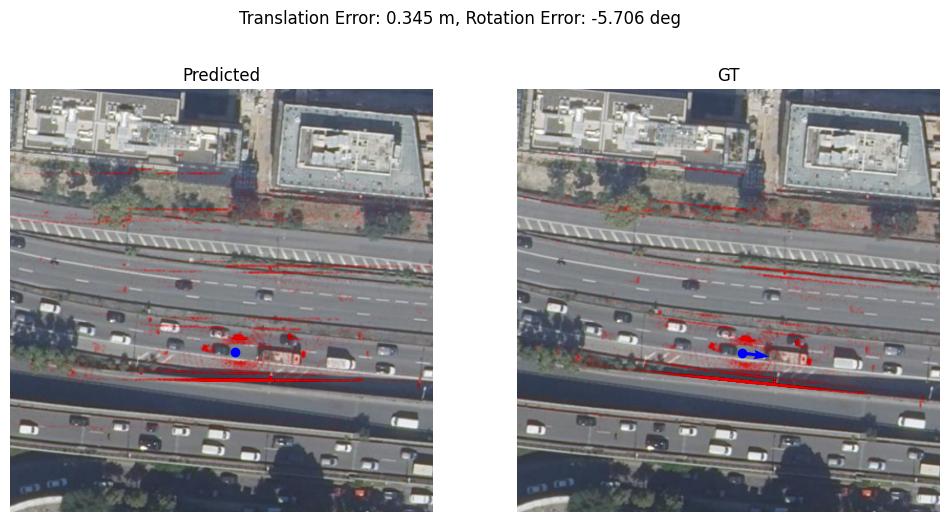

In [155]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

# Predicted
trans_pred = np.array([pred_dx_m, pred_dy_m]).squeeze()
x, y, cx, cy = project_points(pts, rot_pred, trans_pred, res, c)

ax[0].imshow(img, origin="upper")  # origin upper => y down [web:100]
ax[0].scatter(x, y, s=0.1, c="r", alpha=0.1)
ax[0].scatter([cx], [cy], color="b")
#ax[0].quiver([cx], [cy] , rot_pred[1, 0], -rot_pred[0, 0], color='b', scale=15, label='OXTS Heading')
ax[0].set_title("Predicted")
ax[0].set_aspect("equal")
ax[0].set_xticks([]); ax[0].set_yticks([])
ax[0].axis("off")

# GT
x, y, cx, cy = project_points(pts, rot_gt, trans_gt, res, c)

ax[1].imshow(img, origin="upper")  # origin upper => y down [web:100]
ax[1].scatter(x, y, s=0.1, c="r", alpha=0.1)
ax[1].scatter([cx], [cy], color="b")
ax[1].quiver([cx], [cy] , np.sin(np.radians(heading)), np.cos(np.radians(heading)), color='b', scale=15, label='OXTS Heading')
ax[1].set_title("GT")
ax[1].set_aspect("equal")
ax[1].set_xticks([]); ax[1].set_yticks([])
ax[1].axis("off")

title = f"Translation Error: {float(l2_m[0].item()):.3f} m, " \
        f"Rotation Error: {float(dyaw_deg.view(-1)[0].item()):.3f} deg"
fig.suptitle(title)
plt.show()


In [157]:
import numpy as np
import torch
import torch.nn.functional as F

def corr_heatmap_upsampled(corr_fn, sat_size, temperature):
    """
    Returns a numpy heatmap of shape (sat_size, sat_size) in [0,1].
    Uses the center-query correlation like HC-Net.
    """
    corr_map = corr_fn.corr_pyramid[0] if hasattr(corr_fn, "corr_pyramid") else corr_fn
    B = corr_map.shape[0]
    h, w = corr_map.shape[-2:]

    corr5 = corr_map.view(B, h, w, h, w)
    sim = corr5[:, h//2, w//2, :, :][0]  # (h,w)

    prob = F.softmax(sim.reshape(-1) / float(temperature), dim=0).reshape(h, w)  # (h,w)

    prob_up = F.interpolate(
        prob[None, None], size=(sat_size, sat_size),
        mode="bilinear", align_corners=False
    )[0, 0]  # (sat_size,sat_size)

    hm = prob_up.detach().cpu().numpy()
    hm = (hm - hm.min()) / (hm.max() - hm.min() + 1e-12)
    return hm


/tmp/2776263/ipykernel_2508130/1185317310.py:12: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  cx_p = c + float(pred_dx_m) / res
/tmp/2776263/ipykernel_2508130/1185317310.py:13: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  cy_p = c - float(pred_dy_m) / res  # keep your sign convention


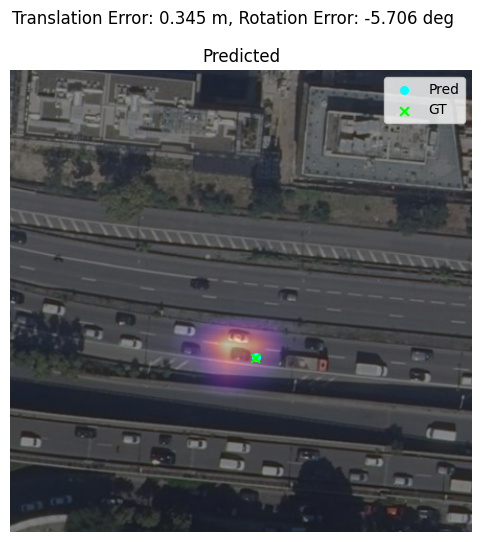

In [158]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, figsize=(6, 6))

sat_size = img.shape[0]  # assuming square; otherwise use args.sat_size
c = (sat_size - 1) / 2
res = float(res)         # meters per pixel scalar

hm = corr_heatmap_upsampled(corr_fn, sat_size=sat_size, temperature=args.temperature)

# --- Predicted panel ---
cx_p = c + float(pred_dx_m) / res
cy_p = c - float(pred_dy_m) / res  # keep your sign convention

# --- GT panel ---
gt_dx = float(trans_gt[ 0]) if np.ndim(trans_gt) else float(trans_gt[0])
gt_dy = float(trans_gt[ 1]) if np.ndim(trans_gt) else float(trans_gt[1])

cx_g = c + gt_dx / res
cy_g = c - gt_dy / res

ax.imshow(img, origin="upper")
ax.imshow(hm, origin="upper", cmap="magma", alpha=0.45)  # transparent overlay [web:21]
ax.scatter([cx_p], [cy_p], color="cyan", s=30, label="Pred")
ax.scatter([cx_g], [cy_g], color="lime", s=40, marker="x", label="GT")

ax.set_title("Predicted")
ax.set_aspect("equal")
ax.set_xticks([]); ax.set_yticks([])
ax.axis("off")
ax.legend()


title = f"Translation Error: {float(l2_m[0].item()):.3f} m, Rotation Error: {float(dyaw_deg.view(-1)[0].item()):.3f} deg"
fig.suptitle(title)
plt.show()


In [88]:
def corr_map_for_visualization(corr_fn, transformed_center=None, sz=(512,512)):
    corr_map = corr_fn.corr_pyramid[0] if hasattr(corr_fn, "corr_pyramid") else corr_fn
    B = corr_map.shape[0]
    h, w = corr_map.shape[-2:]

    if transformed_center is not None:
        # EXACTLY as in corr_loss
        cm = corr_map.view(B, h, w, h, w).permute(0, 3, 4, 1, 2).contiguous().view(B, h*w, h, w)
        tc = transformed_center[:, :, 0] * h / sz[0]                 # scale to corr grid
        tc = 2.0 * tc / (w - 1) - 1.0                                # normalize for grid_sample
        cm = F.grid_sample(cm, tc.view(B,1,1,2), align_corners=True)  # (B,h*w,1,1)
        cm = cm.view(B, h, w)                                        # (B,h,w)
    else:
        cm = corr_map.view(B, h, w, h, w)[:, h//2, w//2, :, :]       # (B,h,w)

    return cm  # (B,h,w)


/tmp/2776263/ipykernel_2508130/1185317310.py:12: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  cx_p = c + float(pred_dx_m) / res
/tmp/2776263/ipykernel_2508130/1185317310.py:13: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  cy_p = c - float(pred_dy_m) / res  # keep your sign convention


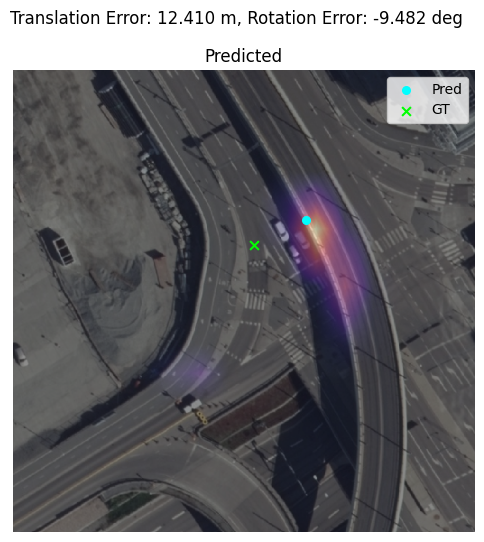

In [67]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, figsize=(6, 6))

sat_size = img.shape[0]  # assuming square; otherwise use args.sat_size
c = (sat_size - 1) / 2
res = float(res)         # meters per pixel scalar

hm = corr_heatmap_upsampled(corr_fn, sat_size=sat_size, temperature=args.temperature)

# --- Predicted panel ---
cx_p = c + float(pred_dx_m) / res
cy_p = c - float(pred_dy_m) / res  # keep your sign convention

# --- GT panel ---
gt_dx = float(trans_gt[ 0]) if np.ndim(trans_gt) else float(trans_gt[0])
gt_dy = float(trans_gt[ 1]) if np.ndim(trans_gt) else float(trans_gt[1])

cx_g = c + gt_dx / res
cy_g = c - gt_dy / res

ax.imshow(img, origin="upper")
ax.imshow(hm, origin="upper", cmap="magma", alpha=0.45)  # transparent overlay [web:21]
ax.scatter([cx_p], [cy_p], color="cyan", s=30, label="Pred")
ax.scatter([cx_g], [cy_g], color="lime", s=40, marker="x", label="GT")

ax.set_title("Predicted")
ax.set_aspect("equal")
ax.set_xticks([]); ax.set_yticks([])
ax.axis("off")
ax.legend()


title = f"Translation Error: {float(l2_m[0].item()):.3f} m, Rotation Error: {float(dyaw_deg.view(-1)[0].item()):.3f} deg"
fig.suptitle(title)
plt.show()


In [58]:
import pandas as pd
good_batches_trans = [[1,985],[28,735],[2,350], [2,575]]
good_batches_rot = [[7,700],[7,955],[1,580],[28,530]]
bad_batches_trans = [[7,2210],[1,285],[2,1235]]
bad_batches_rot = [[7,1560],[2,720],[2,730],[2,965]]
interest_samples = pd.DataFrame(data=good_batches_trans+good_batches_rot+bad_batches_trans+bad_batches_rot,
                columns=['scene_name', 'name'])

In [34]:
max_x = 0
max_y = 0
max_norm = 0

for i in range(200):
    batch = next(iter(val_loader))
    batch = {k: (v.to(device) if torch.is_tensor(v) else v) for k,v in batch.items()}
    trans_gt = batch["translation"]

    x = trans_gt[0,0].detach().cpu().item()
    y = trans_gt[0,1].detach().cpu().item()
    norm = np.sqrt(x**2 + y**2)
    
    if x > max_x:
        max_x = x
        #print(f"Norm : {max_norm:.2f}, x : {max_x:.2f}, y:  {max_y:.2f}")
    if y > max_y:
        max_y = y
        #print(f"Norm : {max_norm:.2f}, x : {max_x:.2f}, y:  {max_y:.2f}")
    if norm > max_norm:
        max_norm = norm
        #print(f"Norm : {max_norm:.2f}, x : {max_x:.2f}, y:  {max_y:.2f}")

        
print(f"\n\n\nFinal\nNorm : {max_norm:.2f}, x : {max_x:.2f}, y:  {max_y:.2f}")

Norm : 22.82, x : 15.69, y:  17.76
Norm : 22.82, x : 18.97, y:  17.76
Norm : 23.38, x : 18.97, y:  17.76
Norm : 23.38, x : 18.97, y:  20.08
Norm : 24.65, x : 18.97, y:  20.08
Norm : 24.65, x : 19.06, y:  20.08
Norm : 24.65, x : 19.75, y:  20.08
Norm : 25.21, x : 19.75, y:  20.08
Norm : 25.21, x : 19.75, y:  21.63
Norm : 25.39, x : 19.75, y:  21.63
Norm : 25.50, x : 19.75, y:  21.63
Norm : 25.50, x : 19.75, y:  21.63
